In [7]:
import torch
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from torch.utils.data import DataLoader
from lightning.pytorch import Trainer

import chm_datamodule

from importlib import reload


<module 'chm_datamodule' from '/n/home10/erolf/tree_mapping/chm_datamodule.py'>

# 1. example of how to generate a dataset for a given site

In [131]:
example_sites = ['KaringaniSite17']
example_site = example_sites[0]

In [132]:
reload(chm_datamodule)
site_dataset = chm_datamodule.get_chm_sites(example_sites, 
                                            layers = ['r','g','b','nir','vis','chm'],
                                            transforms = chm_datamodule.transforms_4_channel_rgbnir_plus_mask)

In [133]:
from torch.utils.data import DataLoader
from torchgeo.datasets import stack_samples
dataloader = DataLoader(site_dataset, batch_size=1, shuffle=True)

sampler = GridGeoSampler(site_dataset, 64, stride=5)

dataloader = DataLoader(
            site_dataset,
            sampler=sampler,
            batch_size=1,
            num_workers=2,
            collate_fn=stack_samples,
        )

In [145]:
dl_enumerator = tqdm.tqdm(dataloader)
device = 'cuda'

with rasterio.open(f'data/int/lidar/lidar_by_site_32736_10m/{example_site}/{example_site}_CHM_10m.tif') as f:
    input_height, input_width = f.shape
    profile = f.profile
    transform = profile["transform"]
            
patch_size = 64
pad = 0
img_nodata_value= -9999.
nodata_value= -9999.
output = np.ones((3, input_height, input_width), dtype=np.float32) * 0
output2 = np.ones((1, input_height, input_width), dtype=np.float32) * 0

with torch.inference_mode():
    for batch in dl_enumerator:
        images = batch["vis"]#.to(device)
        labels = batch["mask"]#.to(device)
        bboxes = batch["bbox"]

        for i in range(len(bboxes)):
            bb = bboxes[i]

            left, top = ~transform * (bb.minx, bb.maxy)
            right, bottom = ~transform * (bb.maxx, bb.miny)
            left, right, top, bottom = int(np.round(left)), int(np.round(right)), int(np.round(top)), int(np.round(bottom))

            assert right - left == patch_size
            assert bottom - top == patch_size


            # image indexed so in integegers top < bottom
            output[:,top+pad:bottom-pad, left+pad:right-pad] = images[i]
            output2[:,top+pad:bottom-pad, left+pad:right-pad] = labels[i]

#             if context_model:
#                 output_context[:,top+pad:bottom-pad, left+pad:right-pad] = context[i][:,pad:-pad, pad:-pad]

100%|██████████| 7055/7055 [00:09<00:00, 734.98it/s]


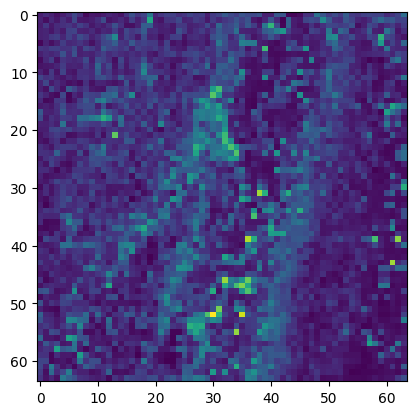

In [130]:
plt.imshow(batch['vis'][0,-1])

In [164]:
# compare with original data sources
with rasterio.open(f'data/int/sentinel/sentinel_by_site_32736_10m/{example_site}/T36JUT_20230418T073611_TCI_10m.tif') as f:
    data = f.read()
    
with rasterio.open(f'data/int/lidar/lidar_by_site_32736_10m/{example_site}/{example_site}_CHM_10m.tif') as f:
    data2 = f.read()

# TODO: compare on the basis of predictions
